In [32]:
import os
print(os.getcwd())

c:\


In [35]:
os.chdir(r"C:\Users\Landl\Downloads\Data-Science-Projects\sec-financial-nlp")
print(os.getcwd())

C:\Users\Landl\Downloads\Data-Science-Projects\sec-financial-nlp


In [36]:
import os
import pickle
import re
import pandas as pd
import torch
from bs4 import BeautifulSoup
from transformers import pipeline


with open("data/processed/all_texts.pkl", "rb") as f:
    all_texts_fixed = pickle.load(f)

print(f"Loaded: {len(all_texts_fixed)} filings")
print(f"GPU: {torch.cuda.is_available()}")

Loaded: 125 filings
GPU: True


In [37]:
def extract_8k_text(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        content = f.read()
    
    documents = content.split("<DOCUMENT>")
    
    target_doc = None
    for doc in documents:
        if doc.strip().startswith("<TYPE>EX-99.1"):
            target_doc = doc
            break
    
    if target_doc is None:
        for doc in documents:
            if doc.strip().startswith("<TYPE>8-K"):
                target_doc = doc
                break
    
    if target_doc is None or len(target_doc) < 200:
        return ""
    
    soup = BeautifulSoup(target_doc, "html.parser")
    for tag in soup.find_all(re.compile(r'^ix:')):
        tag.decompose()
    for tag in soup(["script", "style"]):
        tag.decompose()
    
    text = soup.get_text(separator=" ", strip=True)
    return text[200:] if len(text) > 200 else text


def extract_ceo_quote(text):
    sentences = text.replace('\n', ' ').split('.')
    
    patterns = [
        r'said\s+\w+.*?(?:CEO|Chief Executive|President|Chairman)',
        r'said\s+\w+.*?(?:CFO|Chief Financial)'
    ]
    
    for i, sentence in enumerate(sentences):
        for pattern in patterns:
            if re.search(pattern, sentence, re.IGNORECASE):
                start = max(0, i-3)
                quote_block = '. '.join(sentences[start:i+1])
                if len(quote_block) > 50:
                    return quote_block
    
    return ' '.join(text.split()[:300])

In [38]:
for ticker in ["AAPL", "MSFT", "GOOGL", "JPM", "TSLA"]:
    folder = f"data/raw/sec-edgar-filings/{ticker}/8-K"
    if not os.path.exists(folder):
        continue
    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.endswith(".txt"):
                filepath = os.path.join(root, file)
                key = f"{ticker}_8-K_{os.path.basename(root)}"
                try:
                    text = extract_8k_text(filepath)
                    if len(text) > 500:
                        all_texts_fixed[key] = text
                    else:
                        all_texts_fixed.pop(key, None)
                except Exception as e:
                    print(f"✗ {key} — {e}")

print(f"Total filings: {len(all_texts_fixed)}")

with open("data/processed/all_texts.pkl", "wb") as f:
    pickle.dump(all_texts_fixed, f)

print("Saved.")

KeyboardInterrupt: 

In [ ]:
sample_key = [k for k in all_texts_fixed if "AAPL_8-K" in k][0]
print(all_texts_fixed[sample_key][:400])

ll-time high for all major product categories CUPERTINO, California — July 28, 2022 — Apple ® today announced financial results for its fiscal 2022 third quarter ended June 25, 2022. The Company posted a June quarter revenue record of $83.0 billion, up 2 percent year over year, and quarterly earnings per diluted share of $1.20. “This quarter’s record results speak to Apple’s constant efforts to in


In [ ]:
sentiment_pipeline = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    tokenizer="ProsusAI/finbert",
    device=0
)
print("FinBERT loaded.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FinBERT loaded.


In [ ]:
eightk_keys = [k for k in all_texts_fixed if "8-K" in k]

records = []
skipped = 0

for key in eightk_keys:
    text = all_texts_fixed[key]
    quote = extract_ceo_quote(text)
    
    if len(quote) < 50:
        skipped += 1
        continue
    
    truncated = " ".join(quote.split()[:400])
    result = sentiment_pipeline(truncated, truncation=True, max_length=512)
    
    records.append({
        "key": key,
        "ticker": key.split("_")[0],
        "label": result[0]["label"],
        "score": round(result[0]["score"], 4),
        "quote": quote[:200]
    })

df_sentiment = pd.DataFrame(records)
print(f"Analyzed: {len(records)} filings, Skipped: {skipped}")
print(df_sentiment["label"].value_counts())
print(df_sentiment.groupby("ticker")["label"].value_counts())

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Analyzed: 100 filings, Skipped: 0
label
neutral     64
positive    26
negative    10
Name: count, dtype: int64
ticker  label   
AAPL    neutral      9
        negative     6
        positive     5
GOOGL   neutral     15
        positive     4
        negative     1
JPM     neutral     16
        positive     4
MSFT    neutral     12
        positive     7
        negative     1
TSLA    neutral     12
        positive     6
        negative     2
Name: count, dtype: int64


YES!

In [ ]:
df_sentiment.to_csv("data/processed/sentiment_results.csv", index=False)
print("Saved.")

Saved.


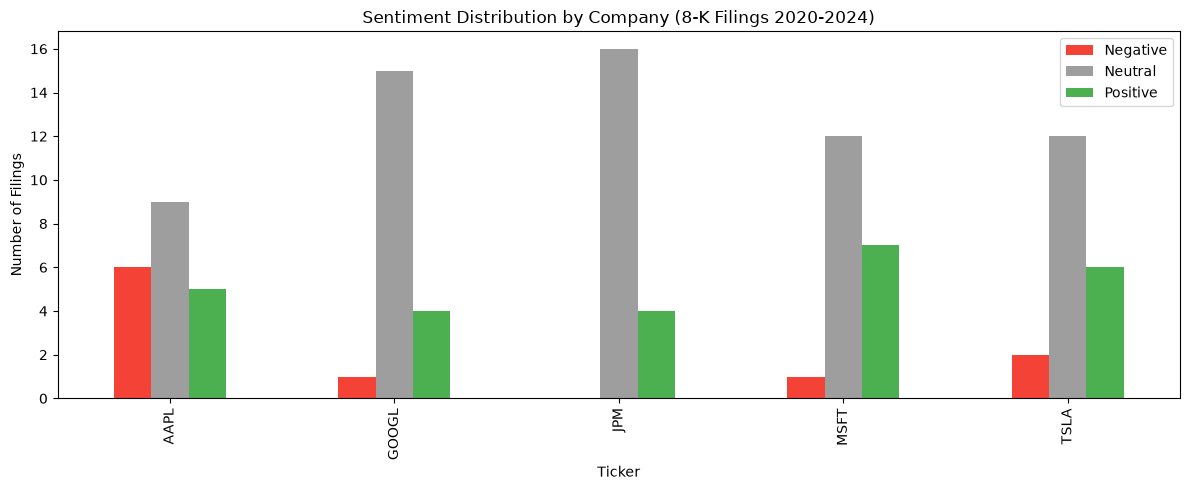

Chart saved.


In [ ]:
# Visualization

import matplotlib.pyplot as plt

df_sentiment.groupby(["ticker", "label"]).size().unstack(fill_value=0).plot(
    kind="bar",
    figsize=(12, 5),
    color=["#F44336", "#9E9E9E", "#4CAF50"]
)
plt.title("Sentiment Distribution by Company (8-K Filings 2020-2024)")
plt.xlabel("Ticker")
plt.ylabel("Number of Filings")
plt.legend(["Negative", "Neutral", "Positive"])
plt.tight_layout()
plt.savefig("notebooks/task1_sentiment.png", dpi=150)
plt.show()
print("Chart saved.")

In [ ]:
from transformers import pipeline

Intent_pipeline = pipeline(
    "zero-shot-classification",
     model="facebook/bart-large-mnli",
    device=0
    )

result = Intent_pipeline(
    "We expect strong revenue growth of 15% next quarter driven by cloud expansion",
candidate_labels=["bullish", "bearish", "hedging", "forward-guidance"]
)

print(result)



Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

{'sequence': 'We expect strong revenue growth of 15% next quarter driven by cloud expansion', 'labels': ['forward-guidance', 'bullish', 'hedging', 'bearish'], 'scores': [0.6548780202865601, 0.3220967650413513, 0.020700568333268166, 0.0023246423806995153]}


In [ ]:
eightk_keys = [k for k in all_texts_fixed if "8-K" in k]

records = []
skipped = 0

for key in eightk_keys:
    text = all_texts_fixed[key]
    quote = extract_ceo_quote(text)

    if len(quote) < 50:
        skipped += 1
        continue

    truncated = " ".join(quote.split()[:400])
    result = Intent_pipeline(
        truncated,
        candidate_labels=["bullish", "bearish", "hedging", "forward-guidance"]
    )

    records.append({
        "key": key,
        "ticker": key.split("_")[0],
        "label": result["labels"][0],
        "score": round(result["scores"][0], 4),
        "quote": quote[:200]
    })

df_intent = pd.DataFrame(records)
print(f"Analyzed: {len(records)} filings, Skipped: {skipped}")
print(df_intent["label"].value_counts())
print(df_intent.groupby("ticker")["label"].value_counts())


Analyzed: 100 filings, Skipped: 0
label
forward-guidance    83
bullish             15
hedging              1
bearish              1
Name: count, dtype: int64
ticker  label           
AAPL    forward-guidance    17
        bullish              3
GOOGL   forward-guidance    18
        bullish              2
JPM     forward-guidance    19
        bullish              1
MSFT    forward-guidance    11
        bullish              7
        bearish              1
        hedging              1
TSLA    forward-guidance    18
        bullish              2
Name: count, dtype: int64


In [ ]:
df_intent.to_csv("data/processed/intent_results.csv", index=False)
print("Saved.")

Saved.


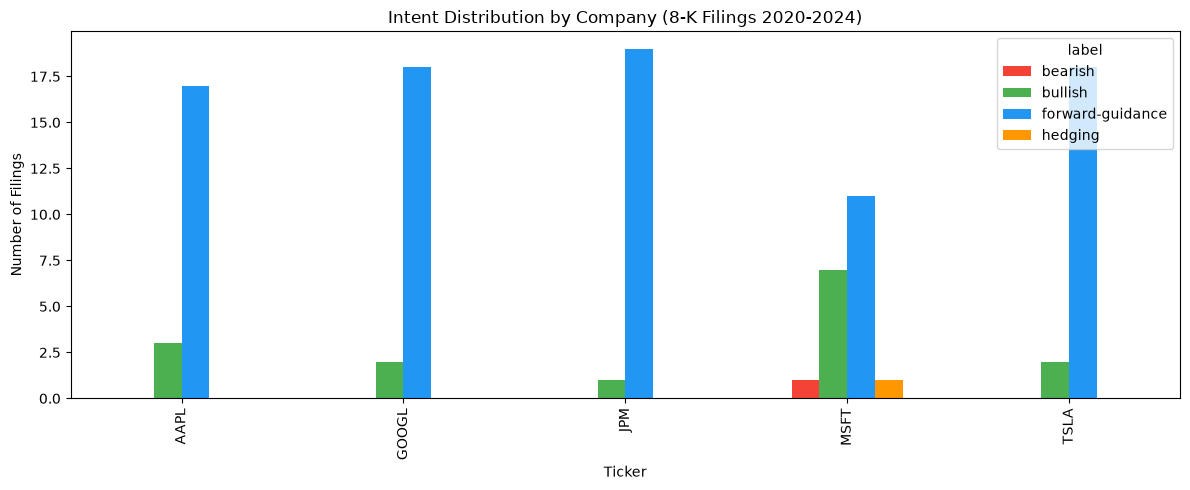

In [ ]:
import matplotlib.pyplot as plt

color_map = {
    "bullish": "#4CAF50",
    "bearish": "#F44336", 
    "hedging": "#FF9800",
    "forward-guidance": "#2196F3"
}

ax = df_intent.groupby(["ticker", "label"]).size().unstack(fill_value=0).plot(
    kind="bar",
    figsize=(12, 5),
    color=[color_map[col] for col in df_intent.groupby(["ticker", "label"]).size().unstack(fill_value=0).columns]
)

plt.title("Intent Distribution by Company (8-K Filings 2020-2024)")
plt.xlabel("Ticker")
plt.ylabel("Number of Filings")
plt.tight_layout()
plt.savefig("notebooks/task1_intent.png", dpi=150)
plt.show()

# Topic Classification

In [ ]:
def chunk_text(text, chunk_size=500):
    words = text.split()
    chunks = []
    
    for i in range(0, len(words), chunk_size):
        chunk = words[i:i+chunk_size]
        chunks.append(" ".join(chunk))
    
    return chunks

In [ ]:
test = "hello " * 1200  # 1200 words
chunks = chunk_text(test)
print(f"Total chunks: {len(chunks)}")
print(f"Words per chunk: {len(chunks[0].split())}")

Total chunks: 3
Words per chunk: 500


In [ ]:
def classify_topics(text):
    chunks = chunk_text(text)
    results = []
    
    for chunk in chunks:
        result = Intent_pipeline(
            chunk,
            candidate_labels=["revenue", "risk", "litigation", "growth", "R&D"]
        )
        results.append({
            "topic": result["labels"][0],
            "score": round(result["scores"][0], 4)
        })
    
    return results

In [ ]:
sample_key = [k for k in all_texts_fixed if "AAPL_10-K" in k][0]
sample_results = classify_topics(all_texts_fixed[sample_key])
print(f"Total chunks classified: {len(sample_results)}")
print(sample_results[:5])

Total chunks classified: 48
[{'topic': 'risk', 'score': 0.3059}, {'topic': 'risk', 'score': 0.4004}, {'topic': 'R&D', 'score': 0.5365}, {'topic': 'risk', 'score': 0.7517}, {'topic': 'risk', 'score': 0.7464}]


In [ ]:
topic_records = []

tenk_keys = [k for k in all_texts_fixed if "10-K" in k]

for key in tenk_keys:
    text = all_texts_fixed[key]
    ticker = key.split("_")[0]
    
    # Only classify first 8 chunks — covers business overview + risk factors
    chunks = chunk_text(text)[:8]
    
    for i, chunk in enumerate(chunks):
        result = Intent_pipeline(
            chunk,
            candidate_labels=["revenue", "risk", "litigation", "growth", "R&D"]
        )
        topic_records.append({
            "key": key,
            "ticker": ticker,
            "chunk": i,
            "topic": result["labels"][0],
            "score": round(result["scores"][0], 4)
        })

df_topics = pd.DataFrame(topic_records)
print(f"Total chunks: {len(df_topics)}")
print(df_topics.groupby(["ticker", "topic"]).size().unstack(fill_value=0))

Total chunks: 200
topic   R&D  growth  revenue  risk
ticker                            
AAPL      4       2        1    33
GOOGL     1       9        8    22
JPM       0      11        0    29
MSFT      3      22        2    13
TSLA      6       6        3    25


In [ ]:
df_topics.to_csv("data/processed/topic_results.csv", index=False)
print("Saved.")

Saved.


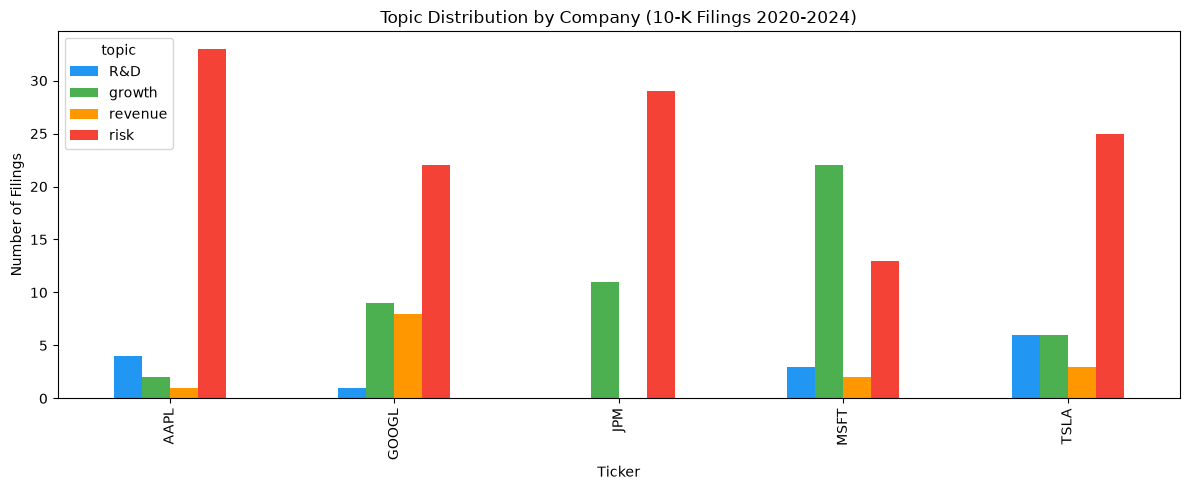

In [ ]:
import matplotlib.pyplot as plt

color_map = {
    "growth": "#4CAF50",
    "risk": "#F44336",
    "revenue": "#FF9800",
    "R&D": "#2196F3",
    "litigation": "#9C27B0"
}

ax = df_topics.groupby(["ticker", "topic"]).size().unstack(fill_value=0).plot(
    kind="bar",
    figsize=(12, 5),
    color=[color_map[col] for col in df_topics.groupby(["ticker", "topic"]).size().unstack(fill_value=0).columns]
)

plt.title("Topic Distribution by Company (10-K Filings 2020-2024)")
plt.xlabel("Ticker")
plt.ylabel("Number of Filings")
plt.tight_layout()
plt.savefig("notebooks/task3_topics.png", dpi=150)
plt.show()

NER

In [ ]:
ner_pipeline = pipeline(
    "token-classification",
    model="dslim/bert-base-NER",
    aggregation_strategy="simple",
    device=0
)
print("NER model loaded.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


NER model loaded.


In [ ]:
import re

def fix_decimal_splits(text):
    # Fix patterns like "$83 . 0 billion" or "$83  0 billion"
    # caused by sentence splitting on periods
    text = re.sub(r'\$(\d+)\s+\.?\s*(\d+)', r'$\1.\2', text)
    # Fix "1 . 20 per" → "1.20 per"
    text = re.sub(r'(\d+)\s+\.\s*(\d+)', r'\1.\2', text)
    return text

In [ ]:
def extract_entities(text):
    # Layer 1 — fix decimal splits before anything else
    text = fix_decimal_splits(text)
    
    # Layer 2 — bert-base-NER for people, companies, locations
    # Truncate to first 100-450 words to avoid hitting max token limit
    truncated = " ".join(text.split()[100:450])
    ner_results = ner_pipeline(truncated)
    
    entities = []
    for e in ner_results:
        entities.append({
            "text": e["word"],
            "type": e["entity_group"],
            "score": round(e["score"], 3)
        })
    
    # Layer 3 — regex for financial-specific entities bert misses
    
    # Money amounts
    money_patterns = re.findall(
        r'\$[\d,]+\.?\d*\s*(?:billion|million|trillion|thousand)?', 
        text, re.IGNORECASE
    )
    for m in money_patterns:
        entities.append({"text": m.strip(), "type": "MONEY", "score": 1.0})
    
    # Ticker symbols — all caps 1-5 letters in parentheses or standalone
    ticker_patterns = re.findall(r'\b([A-Z]{1,5})\b(?:\s*[\(\)])?', text)
    common_tickers = {"AAPL", "MSFT", "GOOGL", "JPM", "TSLA", "GOOG", "AMZN", "NVDA"}
    for t in ticker_patterns:
        if t in common_tickers:
            entities.append({"text": t, "type": "TICKER", "score": 1.0})
    
    # Fiscal periods
    fiscal_patterns = re.findall(
        r'(?:Q[1-4]\s*\d{4}|FY\d{4}|fiscal\s+\d{4})', 
        text, re.IGNORECASE
    )
    for f in fiscal_patterns:
        entities.append({"text": f.strip(), "type": "FISCAL_PERIOD", "score": 1.0})
    
    return entities

In [ ]:
ner_records = []

for key, text in all_texts_fixed.items():
    ticker = key.split("_")[0]
    filing_type = key.split("_")[1]
    entities = extract_entities(text)
    for e in entities:
        ner_records.append({
            "key": key,
            "ticker": ticker,
            "filing_type": filing_type,
            "entity_text": e["text"],
            "entity_type": e["type"],
            "score": e["score"]
        })

df_ner = pd.DataFrame(ner_records)
print(f"Total entities: {len(df_ner)}")

KeyboardInterrupt: 

In [40]:
def is_complete_name(name):
    parts = name.split()
    if len(parts[-1]) < 3:
        return False
    if re.search(r'\s[A-Z]\.?$', name):
        return False
    return True

df_ner = df_ner[~df_ner["entity_text"].str.startswith("##")]
df_ner = df_ner[df_ner["entity_text"].str.len() >= 2]
mask = (df_ner["entity_type"] == "PER") & (~df_ner["entity_text"].str.contains(" "))
df_ner = df_ner[~mask]
df_ner = df_ner[
    (df_ner["entity_type"] != "PER") |
    (df_ner["entity_text"].apply(is_complete_name))
]

df_ner.to_csv("data/processed/ner_results.csv", index=False)
print(f"Final: {len(df_ner)} entities")
print(df_ner[df_ner["entity_type"] == "PER"]["entity_text"].unique())

Final: 7461 entities
['Luca Maestri' 'Tim Cook' 'Amy Hood' 'Ruth Porat' 'Larry Page'
 'Sergey Brin' 'Daniel Pinto' 'Jeremy Barnum' 'Mary Callahan'
 'Marianne Lake' 'Jennifer Roberts' 'Allison Beer' 'Jennifer Piepszak'
 'Troy Rohrbaugh' 'Doug Pet' 'Mark A. Weinberger' 'Alex Gorsky'
 'Jamie Dimon' 'Brad Smith' 'Michele Buck' 'Zachary Kirkhorn'
 'Andrew Baglino' 'James Murdoch']


In [41]:
import pandas as pd
df_ner = pd.read_csv("data/processed/ner_results.csv")
print(f"Entities: {len(df_ner)}")
print(df_ner["entity_type"].value_counts())
print(df_ner[df_ner["entity_type"] == "PER"]["entity_text"].unique())

Entities: 7461
entity_type
MONEY            5079
ORG              1231
MISC              870
FISCAL_PERIOD      95
TICKER             85
LOC                57
PER                44
Name: count, dtype: int64
['Luca Maestri' 'Tim Cook' 'Amy Hood' 'Ruth Porat' 'Larry Page'
 'Sergey Brin' 'Daniel Pinto' 'Jeremy Barnum' 'Mary Callahan'
 'Marianne Lake' 'Jennifer Roberts' 'Allison Beer' 'Jennifer Piepszak'
 'Troy Rohrbaugh' 'Doug Pet' 'Mark A. Weinberger' 'Alex Gorsky'
 'Jamie Dimon' 'Brad Smith' 'Michele Buck' 'Zachary Kirkhorn'
 'Andrew Baglino' 'James Murdoch']
